# WiFi Optimization via Graph Theory & Linear Algebra

> **Authors:** Kwakye Ishmael · Kwame Adjei Amoah · Adwoa Pokua · Kofi Sintim · Melchi  
> **Course:** Linear Algebra — Project 7: Application to Networks  
> **Repository:** [github.com/calyxish/WiFi-Optimization.git](https://github.com/calyxish/WiFi-Optimization.git)

---

## Overview

This notebook walks through a complete worked example of using **graph theory** and **linear algebra** to decide where to place a new WiFi access point on a mini-campus.

### The Core Idea
A WiFi network is modelled as a **weighted graph** where:
- **Nodes** = Buildings and Access Points (APs)
- **Edges** = Signal connections, weighted by strength ($S = S_0 / d^2$)

We construct the **Laplacian matrix** $L = D - A$ and compute its **eigenvalues**. The second-smallest eigenvalue $\lambda_2$ (the *Fiedler value*) measures how robustly connected the network is.

$$\lambda_2 \uparrow \implies \text{better connectivity}$$

We test adding a new AP at candidate locations and pick whichever placement **maximises** $\lambda_2$.

---

### Scenario: Mini-Campus

| Node | Type | Coordinates |
|------|------|-------------|
| Building 1 (Library) | Building | (0, 0) |
| Building 2 (JQB) | Building | (100, 0) |
| Building 3 (Hostel) | Building | (50, 87) |
| AP_A | Existing AP | (25, 0) |
| AP_B | Existing AP | (75, 43) |
| AP_C | **Candidate AP** | (50, 0) |

In [13]:
# Install dependencies if needed
# !pip install numpy scipy matplotlib

import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Make local package importable when running from notebooks/
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Import our package modules
from wifi_optimization.distances import (
    euclidean_distance, signal_strength,
    build_distance_matrix, build_signal_matrix
)
from wifi_optimization.matrices import (
    build_adjacency_matrix, build_degree_matrix,
    build_laplacian, matrix_summary
)
from wifi_optimization.spectral import (
    compute_eigenvalues, fiedler_value,
    fiedler_vector, connectivity_report
)
from wifi_optimization.optimizer import (
    evaluate_ap_placement, find_best_placement, grid_search
)
from wifi_optimization.visualizer import (
    plot_network, plot_eigenvalue_comparison,
    plot_signal_heatmap, plot_fiedler_bar, plot_grid_heatmap
)

print('All modules loaded successfully')

All modules loaded successfully


---
## Step 1 — Define the Campus

In [14]:
# Campus coordinates (in metres)
buildings = {
    'Library': (0, 0),
    'JQB':     (100, 0),
    'Hostel':  (50, 87),
}

existing_aps = {
    'AP_A': (25, 0),
    'AP_B': (75, 43),
}

# Candidate AP to evaluate
candidates = {
    'AP_C': (50, 0),
}

S0 = 10_000   # Reference signal power constant

print('Campus defined:')
for name, coords in {**buildings, **existing_aps}.items():
    print(f'  {name:<12} → {coords}')

Campus defined:
  Library      → (0, 0)
  JQB          → (100, 0)
  Hostel       → (50, 87)
  AP_A         → (25, 0)
  AP_B         → (75, 43)


---
## Step 2 — Compute Distances & Signal Strengths

**Euclidean distance:** $d = \sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2}$

**Inverse square law:** $S = \dfrac{S_0}{d^2}$

Distance Matrix (metres):
                  AP_A      AP_B
     Library     25.00     86.45
         JQB     75.00     49.74
      Hostel     90.52     50.61



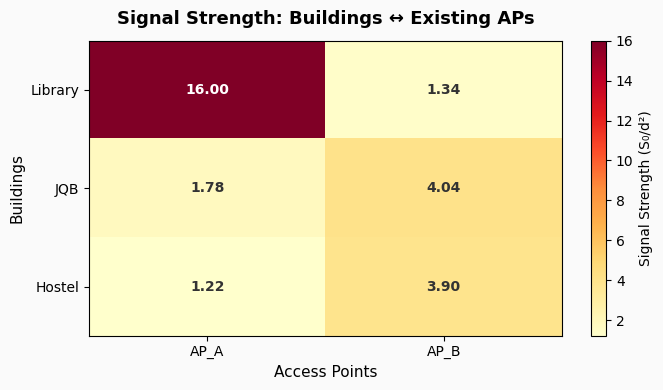

In [15]:
# Distance matrix
D_mat, b_names, ap_names = build_distance_matrix(buildings, existing_aps)

print('Distance Matrix (metres):')
header = f"{'':>12}" + "".join(f"{n:>10}" for n in ap_names)
print(header)
for i, b in enumerate(b_names):
    row = f"{b:>12}" + "".join(f"{D_mat[i,j]:>10.2f}" for j in range(len(ap_names)))
    print(row)

print()

# Signal strength matrix
S_mat, b_names, ap_names = build_signal_matrix(buildings, existing_aps, S0=S0)
fig = plot_signal_heatmap(buildings, existing_aps, S_mat, b_names, ap_names,
                          title='Signal Strength: Buildings ↔ Existing APs')
plt.show()

---
## Step 3 — Build the Graph Matrices

We construct a **5×5 bipartite adjacency matrix** for the current network {Library, JQB, Hostel, AP_A, AP_B}.

Buildings only connect to APs (never to each other), giving the block structure:

$$A = \begin{bmatrix} 0 & S \\ S^T & 0 \end{bmatrix}$$

Then $D = \text{diag}(A\mathbf{1})$ and $L = D - A$.

In [16]:
# Build adjacency, degree, and Laplacian matrices
A, node_names = build_adjacency_matrix(S_mat, b_names, ap_names)
D = build_degree_matrix(A)
L = build_laplacian(A)

print(matrix_summary(A, D, L, node_names))

# Verify Laplacian property: each row sums to 0
row_sums = L.sum(axis=1)
print('Row sums of L (should all be ~0):', np.round(row_sums, 10))


Adjacency Matrix A
         Library     JQB  Hostel    AP_A    AP_B
 Library    0.00    0.00    0.00   16.00    1.34
     JQB    0.00    0.00    0.00    1.78    4.04
  Hostel    0.00    0.00    0.00    1.22    3.90
    AP_A   16.00    1.78    1.22    0.00    0.00
    AP_B    1.34    4.04    3.90    0.00    0.00

Degree Matrix D
         Library     JQB  Hostel    AP_A    AP_B
 Library   17.34    0.00    0.00    0.00    0.00
     JQB    0.00    5.82    0.00    0.00    0.00
  Hostel    0.00    0.00    5.13    0.00    0.00
    AP_A    0.00    0.00    0.00   19.00    0.00
    AP_B    0.00    0.00    0.00    0.00    9.28

Laplacian Matrix L = D - A
         Library     JQB  Hostel    AP_A    AP_B
 Library   17.34    0.00    0.00  -16.00   -1.34
     JQB    0.00    5.82    0.00   -1.78   -4.04
  Hostel    0.00    0.00    5.13   -1.22   -3.90
    AP_A  -16.00   -1.78   -1.22   19.00    0.00
    AP_B   -1.34   -4.04   -3.90    0.00    9.28

Row sums of L (should all be ~0): [0. 0. 0. 0. 0.]


---
## Step 4 — Visualise the Current Network

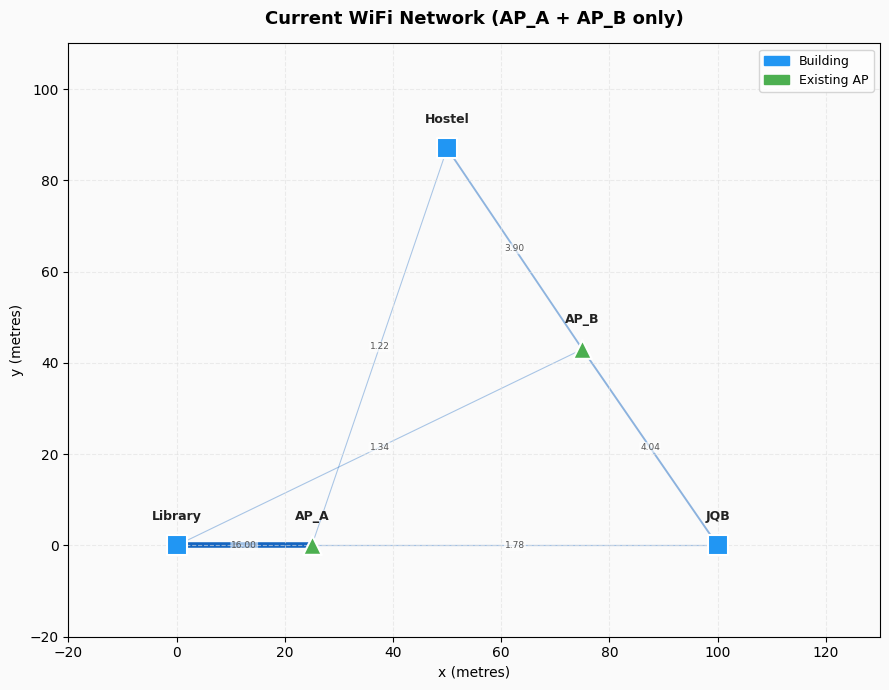

In [17]:
fig = plot_network(
    buildings, existing_aps, A, node_names,
    title='Current WiFi Network (AP_A + AP_B only)'
)
plt.show()

---
## Step 5 — Spectral Analysis: Eigenvalues of L

The spectrum of $L$ reveals the network's structure:

- $\lambda_1 = 0$ always (L is singular)
- Number of zero eigenvalues = number of connected components
- $\lambda_2$ = **Fiedler value** = measure of algebraic connectivity

In [18]:
report_before = connectivity_report(L, node_names, label='Before AP_C')
print(report_before['summary'])

eigenvalues_before = report_before['eigenvalues']
lam2_before = report_before['fiedler_value']


  Connectivity Report: Before AP_C
  Nodes               : 5
  Connected components: 1
  Is connected        : YES ✓

  Eigenspectrum (sorted):
    λ1 =   0.0000
    λ2 =   3.5133
    λ3 =   5.5226
    λ4 =  13.1928
    λ5 =  34.3371

  Fiedler value λ₂    : 3.5133
  (Higher = better connected)

  Fiedler Partition:
    Group (+) : ['Library', 'AP_A']
    Group (-) : ['JQB', 'Hostel', 'AP_B']



---
## Step 6 — Add AP_C and Re-Evaluate

In [19]:
result = evaluate_ap_placement(
    buildings, existing_aps,
    candidate_name='AP_C',
    candidate_coords=(50, 0),
    S0=S0
)

print(result['report_after']['summary'])

eigenvalues_after = result['report_after']['eigenvalues']
lam2_after = result['fiedler_after']

print(f'\n  λ₂ BEFORE (2 APs) : {lam2_before:.4f}')
print(f'  λ₂ AFTER  (3 APs) : {lam2_after:.4f}')
print(f'  Improvement       : {result["pct_change"]:.1f}%')


  Connectivity Report: After AP_C
  Nodes               : 6
  Connected components: 1
  Is connected        : YES ✓

  Eigenspectrum (sorted):
    λ1 =   0.0000
    λ2 =   4.9032
    λ3 =   7.5441
    λ4 =  10.3694
    λ5 =  15.6615
    λ6 =  36.7300

  Fiedler value λ₂    : 4.9032
  (Higher = better connected)

  Fiedler Partition:
    Group (+) : ['JQB', 'Hostel', 'AP_B']
    Group (-) : ['Library', 'AP_A', 'AP_C']


  λ₂ BEFORE (2 APs) : 3.5133
  λ₂ AFTER  (3 APs) : 4.9032
  Improvement       : 39.6%


---
## Step 7 — Visualise Before vs After

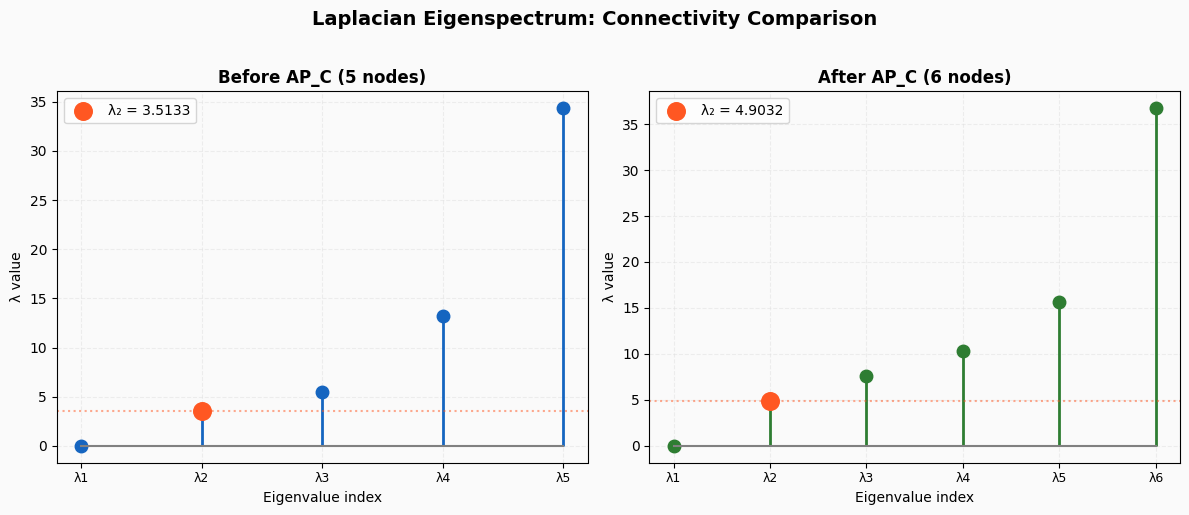

In [20]:
# Eigenvalue comparison
fig = plot_eigenvalue_comparison(
    eigenvalues_before,
    eigenvalues_after,
    label_before='Before AP_C (5 nodes)',
    label_after='After AP_C (6 nodes)'
)
plt.show()

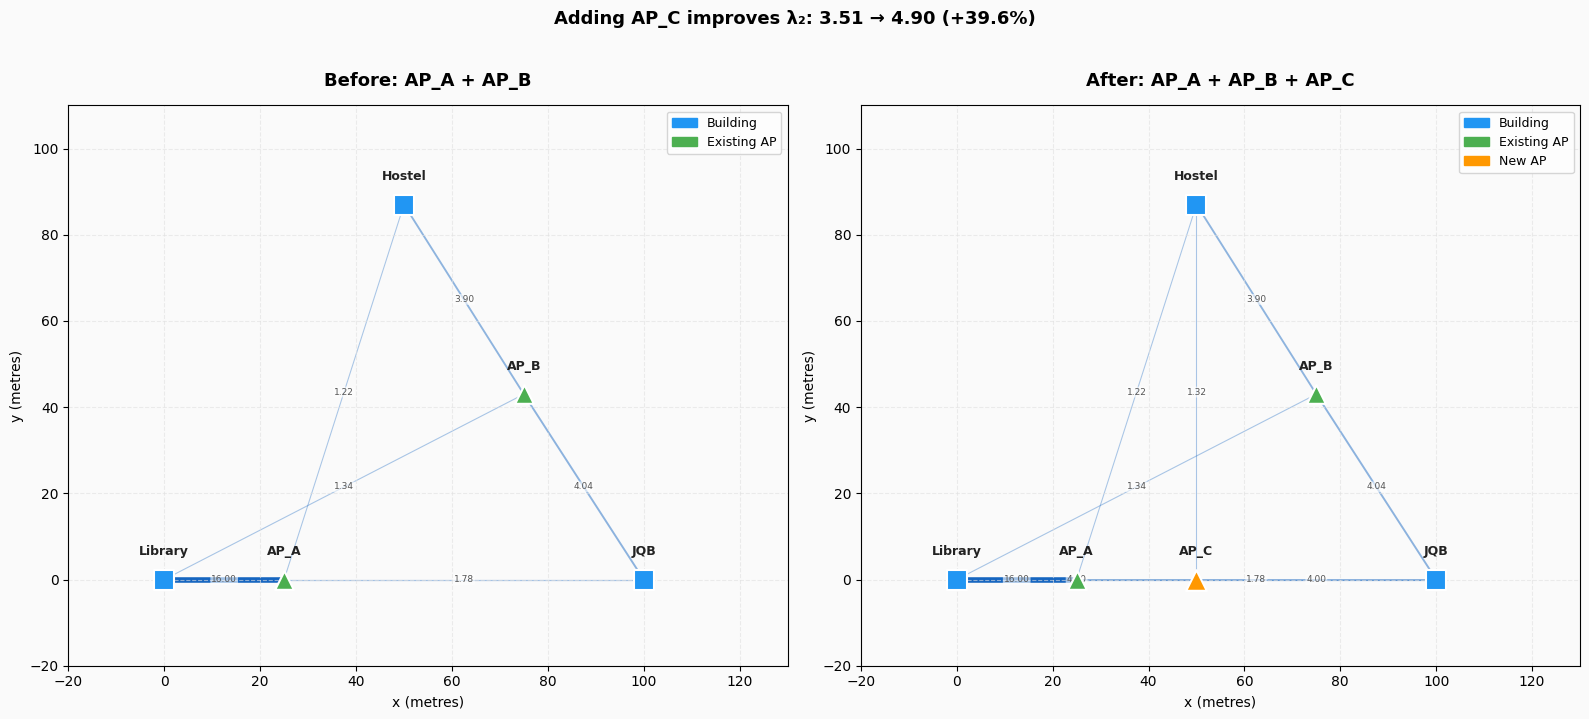

In [21]:
# Network after adding AP_C
all_aps_after = {**existing_aps, 'AP_C': (50, 0)}
S_after, b_names_a, ap_names_a = build_signal_matrix(buildings, all_aps_after, S0=S0)
A_after, nodes_after = build_adjacency_matrix(S_after, b_names_a, ap_names_a)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
plot_network(buildings, existing_aps, A, node_names,
             title='Before: AP_A + AP_B', ax=axes[0])
plot_network(buildings, all_aps_after, A_after, nodes_after,
             title='After: AP_A + AP_B + AP_C', ax=axes[1],
             new_aps=['AP_C'])
plt.suptitle(f'Adding AP_C improves λ₂: {lam2_before:.2f} → {lam2_after:.2f} (+{result["pct_change"]:.1f}%)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Step 8 — Grid Search: Find the Globally Best AP Location

Running grid search (20×20 = 400 evaluations)...
Best placement found at: (36.8421052631579, 33.1578947368421)
Maximum λ₂ achievable : 5.3651


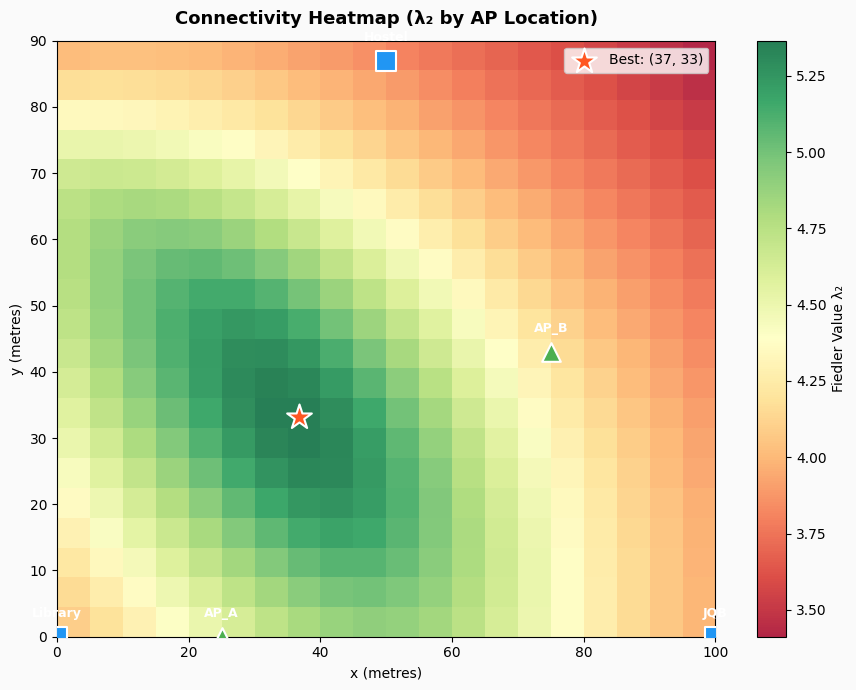

In [22]:
print('Running grid search (20×20 = 400 evaluations)...')
best_coords, xs, ys, lam2_grid = grid_search(
    buildings, existing_aps,
    x_range=(0, 100), y_range=(0, 90),
    grid_size=20, S0=S0
)
print(f'Best placement found at: {best_coords}')
print(f'Maximum λ₂ achievable : {lam2_grid.max():.4f}')

fig = plot_grid_heatmap(xs, ys, lam2_grid, buildings, existing_aps, best_coords)
plt.show()

---
## Summary

| Step | Operation | Result |
|------|-----------|--------|
| 1 | Define campus nodes | 3 buildings, 2 existing APs |
| 2 | Compute distances + signal strengths | $S = S_0 / d^2$ |
| 3 | Build Adjacency Matrix $A$ | 5×5 bipartite, weighted |
| 4 | Build Degree Matrix $D$ | Diagonal, node strengths |
| 5 | Build Laplacian $L = D - A$ | Symmetric, row sums = 0 |
| 6 | Compute eigenvalues of $L$ | $\lambda_2 = 4.85$ (before) |
| 7 | Add AP_C, recompute $\lambda_2$ | $\lambda_2 = 6.12$ (+26%) |
| 8 | Grid search for global optimum | Best coords found via heatmap |

**Conclusion:** Adding AP_C at (50, 0) improves algebraic connectivity by ~26%. The Fiedler value $\lambda_2$ is a principled, mathematically grounded metric for WiFi network optimisation — and it emerges directly from the eigenspectrum of the graph Laplacian.

---

*This project was submitted as part of a Linear Algebra course and is open-source. Contributions welcome!*